# Regression task to calculate the energy generated per hour

Features - Temperature (AT) - celcius, Exhaust Vacuum (V), Ambient Pressure (AP) - Milibar, Relative Humidity (RH) - percentage
Target - Energy Output (PE)

In [1]:
import numpy as np
import pandas as pd
import pprint

import sklearn
from sklearn import preprocessing
from sklearn.model_selection import train_test_split 
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
def model_estimators(X, y, test_size, models):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=10)
    
    for model in models:
        print(getattr(model, '__name__', repr(model)))
        reg_model = model()
        reg_model.fit(X=X_train, y=y_train)
        if(getattr(model, '__name__', repr(model)) == 'RandomForestRegressor') :
            #print(reg_model.feature_importances_)
            coef = reg_model.feature_importances_
        else:
            #print(reg_model.coef_)
            coef = reg_model.coef_
        
        pprint.pprint(dict(zip(list(X), coef)))
        print('train_score ' , reg_model.score(X=X_train, y=y_train), ', test_score' , reg_model.score(X_test,y_test), "\n\n")
        

def cv_estimators(X, y, n_cv, models):
        
    for model in models:
        print(getattr(model, '__name__', repr(model)))
        reg_model = model()
        model_results = cross_validate(reg_model, X, y, cv=n_cv, scoring=('r2'), return_train_score=True)
        pprint.pprint(model_results, width=1 )
        '''if(getattr(model, '__name__', repr(model)) == 'RandomForestRegressor') :
            print(reg_model.feature_importances_)
        else:
            print(reg_model.coef_)
        
        print('train_score ' , reg_model.score(X=X_train, y=y_train), ', test_score' , reg_model.score(X_test,y_test), "\n\n")'''
        print("\n\n")        

In [3]:
data = pd.read_csv("CCPP_data.csv")
data.shape

(9568, 5)

In [4]:
data.head(5)

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [5]:
data.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [6]:
X = data.drop('PE', axis=1)
y = data['PE']

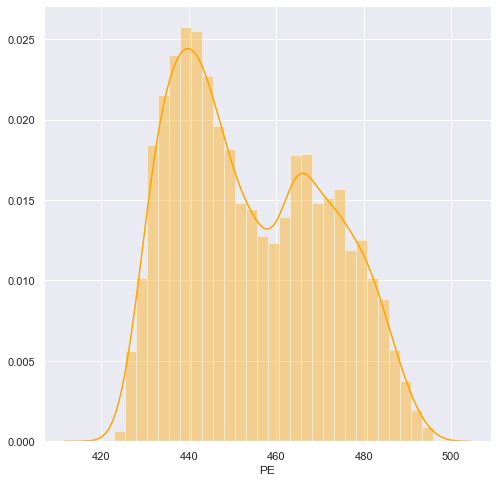

In [7]:
sns.set(rc={'figure.figsize':(8,8)})
sns.distplot(y, bins=30, color='orange')
plt.show()

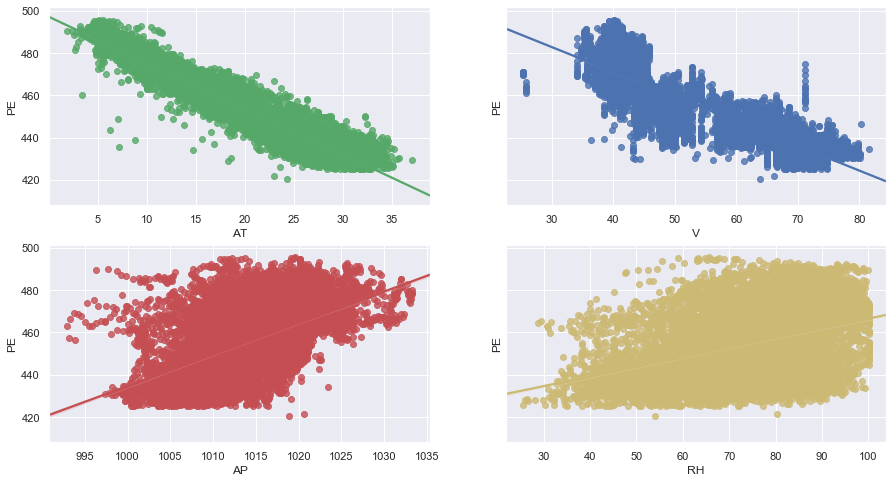

In [8]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, sharey=True, figsize=(15, 8))
sns.regplot(x=X['AT'], y=y, color="g", ax=ax1)
sns.regplot(x=X['V'], y=y, color="b", ax=ax2)
sns.regplot(x=X['AP'], y=y, color="r", ax=ax3)
sns.regplot(x=X['RH'], y=y, color="y", ax=ax4)

# Use linear regression and random forest

In [9]:
model_estimators(X,y, 0.25, [LinearRegression, Lasso, Ridge, RandomForestRegressor])

LinearRegression
{'AP': 0.06503422767916059,
 'AT': -1.9672271783343964,
 'RH': -0.1537426253550895,
 'V': -0.2348835436986609}
train_score  0.926898923098205 , test_score 0.9338474065790864 


Lasso
{'AP': 0.05233104525405018,
 'AT': -1.9113355379594736,
 'RH': -0.1380947233690061,
 'V': -0.2531383788652596}
train_score  0.9266724415802144 , test_score 0.9333327560540788 


Ridge
{'AP': 0.06504145716983889,
 'AT': -1.967198641113893,
 'RH': -0.15373782190359722,
 'V': -0.23489428519877417}
train_score  0.926898923072277 , test_score 0.9338473277464179 


RandomForestRegressor
{'AP': 0.019451432722535866,
 'AT': 0.8884570393689802,
 'RH': 0.018210471329558157,
 'V': 0.07388105657892577}
train_score  0.9923249357090824 , test_score 0.9621810440811991 




# Conclusion 1
* Train and Test scores of Linear, Lasso and Ridge regression are very close. The data is neither overfitting nor underfitting
* Random forest gives very good result. Training score is more than 99% and test score is ~96%
* weight of Ambient Temperature (AT) is higher compared to other features. It is influencing the results more compared to other features. The data plotted above also indicate the same thing.
* AT is linearly related to the target (PE)

# Cross validation

In [10]:
cv_estimators(X,y, 5, [LinearRegression, Lasso, Ridge, RandomForestRegressor])

LinearRegression
{'fit_time': array([0.00321555, 0.00200844, 0.00236416, 0.00200105, 0.00099945]),
 'score_time': array([0.00136542, 0.00100756, 0.0010047 , 0.        , 0.00100207]),
 'test_score': array([0.93053597, 0.92681472, 0.93389127, 0.92680208, 0.92464499]),
 'train_score': array([0.92820287, 0.92913257, 0.92734539, 0.92915296, 0.92967841])}



Lasso
{'fit_time': array([0.00199986, 0.00200176, 0.00199986, 0.00200319, 0.00300002]),
 'score_time': array([0.        , 0.00099874, 0.00099993, 0.00099897, 0.        ]),
 'test_score': array([0.92997539, 0.92633875, 0.9335672 , 0.92691937, 0.92477259]),
 'train_score': array([0.92798144, 0.92890639, 0.9271201 , 0.92892664, 0.92945605])}



Ridge
{'fit_time': array([0.00199986, 0.00100017, 0.00099945, 0.00099897, 0.0410037 ]),
 'score_time': array([0.        , 0.00100017, 0.00100112, 0.        , 0.00050259]),
 'test_score': array([0.93053586, 0.92681471, 0.93389117, 0.92680217, 0.92464512]),
 'train_score': array([0.92820287, 0.92913257

# Conclusion 2
* No major effect of using cross validation with regression models
* train and test result of each cross validation are comparable for every model.
* Randomforest takes significantly high time compared to linear models

# Feature Scaling

In [11]:
min_max_scaler = preprocessing.MinMaxScaler()
X_scaled = min_max_scaler.fit_transform(X)
data_scaled = pd.DataFrame(X_scaled)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,AT,V,AP,RH
0,0.372521,0.291815,0.771591,0.638204
1,0.662040,0.669039,0.671863,0.449330
2,0.093484,0.249822,0.476862,0.892493
3,0.539660,0.568683,0.429349,0.684718
4,0.255241,0.216014,0.404355,0.952547


In [12]:
model_estimators(X_scaled,y, 0.25, [LinearRegression, Lasso, Ridge, RandomForestRegressor])

LinearRegression
{'AP': 2.6280331405148747,
 'AT': -69.44311939520426,
 'RH': -11.469199851489641,
 'V': -13.200455155864752}
train_score  0.926898923098205 , test_score 0.9338474065790864 


Lasso
{'AP': 0.0, 'AT': -43.02603515461015, 'RH': 0.0, 'V': -12.09927039868422}
train_score  0.8345334542798801 , test_score 0.8365378504288814 


Ridge
{'AP': 2.9833340409297486,
 'AT': -68.26107225096678,
 'RH': -11.00438925084005,
 'V': -13.869493915734848}
train_score  0.9268626110330859 , test_score 0.9337057922338703 


RandomForestRegressor
{'AP': 0.019480719076970448,
 'AT': 0.890343544227298,
 'RH': 0.017605531687608086,
 'V': 0.07257020500812354}
train_score  0.991803073069509 , test_score 0.9618614233840286 




# Conclusion 3
* feature scaling does not improves or degrades performance for this dataset

In [13]:
cv_estimators(X_scaled,y, 5, [LinearRegression, Lasso, Ridge, RandomForestRegressor])

LinearRegression
{'fit_time': array([0.00300598, 0.00200963, 0.00206661, 0.00221086, 0.00099969]),
 'score_time': array([0.00099897, 0.        , 0.        , 0.        , 0.0010016 ]),
 'test_score': array([0.93053597, 0.92681472, 0.93389127, 0.92680208, 0.92464499]),
 'train_score': array([0.92820287, 0.92913257, 0.92734539, 0.92915296, 0.92967841])}



Lasso
{'fit_time': array([0.00200152, 0.00199771, 0.00099969, 0.00099993, 0.0010004 ]),
 'score_time': array([0.        , 0.        , 0.00100112, 0.00099921, 0.00100017]),
 'test_score': array([0.83455408, 0.83417842, 0.83779358, 0.83812622, 0.83727959]),
 'train_score': array([0.83715908, 0.83733172, 0.83450166, 0.83641698, 0.83729995])}



Ridge
{'fit_time': array([0.00199866, 0.00100017, 0.00200152, 0.00099969, 0.00199986]),
 'score_time': array([0.        , 0.00099969, 0.        , 0.00099921, 0.        ]),
 'test_score': array([0.93037411, 0.92677795, 0.93373734, 0.92689053, 0.92475961]),
 'train_score': array([0.92817171, 0.92910051